In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import entropy
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from scipy.stats import entropy
from tqdm import tqdm

In [5]:
plt.style.use(
    '../Dataset-And-Solve-Class/class-12-ML-how-machine-learns/class-12-deeplearning.mplstyle'
)

In [ ]:
# Load dataset
# Task: Tabuler Regression
housing_dataset = pd.read_csv(
    '../Dataset-And-Solve-Class/class-13-regression-analysis-and-bias-variance/class-13-housing.csv',
)
housing_dataset.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [8]:
housing_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [10]:
housing_dataset.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [12]:
housing_dataset.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [13]:
"""
THEORETICAL CONCEPT: Feature Selection
- Remove irrelevant or redundant columns.
- Keep only predictive features and target.
"""
housing_dataset = housing_dataset[[
    'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
    'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
    'parking', 'prefarea', 'furnishingstatus', 'price'
]]

print("Selected columns:", housing_dataset.columns.tolist())

Selected columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus', 'price']


In [16]:
housing_dataset.isnull().sum()

area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
price               0
dtype: int64

In [17]:
# Separate numerical and categorical columns
numerical_cols = housing_dataset.select_dtypes(include='number').columns.drop('price') # here we are taking colums which data type number and also drope 'price' col because it is our target/result/output col
categorical_cols = housing_dataset.select_dtypes(include='object').columns # col that are not numaric

print("Numerical columns:", numerical_cols.tolist())
print("Categorical columns:", categorical_cols.tolist())

Numerical columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [19]:
scaler = StandardScaler()

housing_dataset[numerical_cols]

,area,bedrooms,bathrooms,stories,parking
0,7420,4,2,3,2
1,8960,4,4,4,3
2,9960,3,2,2,2
3,7500,4,2,2,3
4,7420,4,1,2,2
...,...,...,...,...,...
540,3000,2,1,1,2
541,2400,3,1,1,0
542,3620,2,1,1,0
543,2910,3,1,1,0


In [21]:
#Normalization/standarization apply on numarical column
housing_dataset[numerical_cols] = scaler.fit_transform(housing_dataset[numerical_cols])
housing_dataset[numerical_cols]

,area,bedrooms,bathrooms,stories,parking
0,1.046726,1.403419,1.421812,1.378217,1.517692
1,1.757010,1.403419,5.405809,2.532024,2.679409
2,2.218232,0.047278,1.421812,0.224410,1.517692
3,1.083624,1.403419,1.421812,0.224410,2.679409
4,1.046726,1.403419,-0.570187,0.224410,1.517692
...,...,...,...,...,...
540,-0.991879,-1.308863,-0.570187,-0.929397,1.517692
541,-1.268613,0.047278,-0.570187,-0.929397,-0.805741
542,-0.705921,-1.308863,-0.570187,-0.929397,-0.805741
543,-1.033389,0.047278,-0.570187,-0.929397,-0.805741


In [23]:
#Encoding the categorical column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

housing_dataset[categorical_cols]

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,yes,no,yes,no,furnished
...,...,...,...,...,...,...,...
540,yes,no,yes,no,no,no,unfurnished
541,no,no,no,no,no,no,semi-furnished
542,yes,no,no,no,no,no,unfurnished
543,no,no,no,no,no,no,furnished


In [24]:
for col in categorical_cols:
    housing_dataset[col] = le.fit_transform(housing_dataset[col])

housing_dataset[categorical_cols]

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,1,0,0,0,1,1,0
1,1,0,0,0,1,0,0
2,1,0,1,0,0,1,1
3,1,0,1,0,1,1,0
4,1,1,1,0,1,0,0
...,...,...,...,...,...,...,...
540,1,0,1,0,0,0,2
541,0,0,0,0,0,0,1
542,1,0,0,0,0,0,2
543,0,0,0,0,0,0,0


In [26]:
housing_dataset['guestroom'].value_counts() # 0 value 448 and 1 value 97

guestroom
0    448
1     97
Name: count, dtype: int64

In [28]:
# Separate input values and target values
X = housing_dataset.drop('price', axis=1).values #input col all except price col
y = housing_dataset['price'].values #price col is output col
print(X.shape)
print(y.shape)

(545, 12)
(545,)


In [ ]:
# First split: 80% train+val, 20% test

#X_train_val = input train 0.8 or 80% data (all col except price) = (436, 12)
#y_train_val = output 80% data of the correspondin X_train_val (price col) = (436,) <- price col only [output]

#X_test = input 20% test data = (109, 12)
#y_test = output 20% test data = (109,) <- only price [output]

"""
random_state=42 = fixed seed of data. Without using it, if we re-run the whole code, 
the train, test split will be changed. Problem: accuracy will be changed. same as random.seed(), 
keep the train-test split same and do not change the accuracy.  
"""

X_train_val, X_test, y_train_val, y_test = train_test_split( 
    X, y, test_size=0.2, random_state=42
)

X_train_val.shape, y_train_val.shape, X_test.shape, y_test.shape

((436, 12), (436,), (109, 12), (109,))

In [ ]:
# Second split: 75% train, 25% validation from train_val ( 436 or 80% of the main dataset)

#X_train = input 75% train     = 327
#y_train = output 25% train    = 327

#X_val = input 75% validation  = 109
#y_val = output 25% validation = 109
#-------------------------------------
#total data                    = 327 + 109 
#                              = 436 (80 % of main train data - 'see previous code block')

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

In [33]:
print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 327, Val size: 109, Test size: 109


In [36]:
def model(x, w, b):
    y_pred = np.dot(x, w) + b #multiple feature * multiple weight
    return  y_pred

In [37]:
def cost_function(x, y, w, b):
    """Compute Mean Squared Error"""
    y_pred = model(x, w, b)
    mse = np.mean((y - y_pred) ** 2)
    return mse

In [ ]:
def compute_gradient(x, y_true, w, b):
    delta = 1e-9
    cost_1 = cost_function(x, y_true, w, b) #main cost
    cost_2 = cost_function(x, y_true, w + delta, b) #cost after small change in w
    cost_3 = cost_function(x, y_true, w, b + delta) #cost after small change in b
    dw = (cost_2 - cost_1) / delta
    db = (cost_3 - cost_1) / delta #calculate dw, db
    return dw, db

In [ ]:
"""
THEORETICAL CONCEPT: Model Training
- Initialize weights to small random values or zeros
- Use small learning rate for stability
- Monitor training and validation loss
"""

# Initialize parameters
np.random.seed(142) #reproducible random [do not change next time/keep same random every iteration/run the program]
w_init = np.random.randn(X_train.shape[1]) * 0.01 # np.random.randn(12) * 0.01, here, 12 is no of column, it'll genereate 12 random and multiply 0.01
b_init = 0.0

w_init

array([ 0.0012974 ,  0.00902362,  0.01005804,  0.0047189 , -0.00326213,
       -0.0026265 , -0.00368877,  0.01478741,  0.01299381, -0.00525526,
       -0.00536705,  0.00454478])

In [ ]:
# Hyperparameters [not real parameter of the dataset]
learning_rate = 0.01
epochs = 50000 #iteration

In [ ]:
# Train model
def fit(
        X_train, y_train, w_init, b_init, learning_rate, epochs, X_val=None, y_val=None #taking all paramentes
):
    w = w_init.copy()
    b = b_init
    train_losses, val_losses = [], [] #tracking train and validation loss
    
    for i in range(epochs): #iteration based on the value of epochs
        dw, db = compute_gradient(X_train, y_train, w, b) #calculate gradient using train data
        w -= learning_rate * dw #small change in w
        b -= learning_rate * db #small change in b
    
        if i % 100 == 0: #append loss in tracking array after 100 epoche
            train_loss = cost_function(X_train, y_train, w, b) #loss calculate using input(X_train), ouput(y_train), w, b
            train_losses.append(train_loss) #store the loss in train_losses array
            if X_val is not None and y_val is not None:
                val_loss = cost_function(X_val, y_val, w, b) #loss calculate using the validation data
                val_losses.append(val_loss) #store the val loss
            else:
                val_losses.append(None)
    return w, b, train_losses , val_losses #return w, b and train, vlidation loss

In [42]:
# Train model
w_final, b_final, train_losses, val_losses = fit(
    X_train, y_train, w_init, b_init, learning_rate, epochs, X_val, y_val
)

In [43]:
print("Training completed.")
print(f"Final training loss: {train_losses[-1] // 1e9:.4f}")
print(f"Final validation loss: {val_losses[-1] // 1e9:.4f}")

Training completed.
Final training loss: 1399.0000
Final validation loss: 1445.0000


In [ ]:
"""
THEORETICAL CONCEPT: K-Fold Cross-Validation 
- Splits data into K folds
- Train on K-1, validate on 1 → repeat K times
- Average performance → reduces variance in evaluation
- Especially useful with small datasets because of multiple iteration - K times
""";

kf = KFold(n_splits=5, shuffle=True, random_state=42) #total 5 fold, shuffle [every fold will be used for at least one time for train, test], reproducilble
cv_mse_scores = []

print("Performing 5-Fold Cross-Validation...")
#fold -> fold values, train_idx, val_idx -> index of train and validation fold
#X_train_val[train_idx] -> take the specific index value for X_train [input train]
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_val)): #kf.split(X_train_val) -> split only train data [we don't touch test data during training]
    X_fold_train, X_fold_val = X_train_val[train_idx], X_train_val[val_idx] #X_fold_train -> input train fold, X_fold_val -> input validation fold
    y_fold_train, y_fold_val = y_train_val[train_idx], y_train_val[val_idx] #y_fold_train -> output train fold, y_fold_val -> output validation fold

    # Re-initialize model
    w_fold = np.random.randn(X_fold_train.shape[1]) * 0.01 # weight-> w , 0.01-> learning_rate
    b_fold = 0.0 #bias-> b

    # Train [Start training]
    w_fold, b_fold, _, _ = fit(
        X_fold_train, y_fold_train, w_fold, b_fold, learning_rate, epochs
    )

    # Evaluate
    y_pred_val = X_fold_val @ w_fold + b_fold #@ perform dot product (w multipy with other fold)
    mse = mean_squared_error(y_fold_val, y_pred_val) #mean_squared_error(original value/price, predicted value/price)
    cv_mse_scores.append(mse)
    print(f"  Fold {fold+1} MSE: {mse:.4f}")

print(f"Cross-Validation MSE: {np.mean(cv_mse_scores):.4f} ± {np.std(cv_mse_scores):.4f}")

Performing 5-Fold Cross-Validation...
  Fold 1 MSE: 1572996946958.6743
  Fold 2 MSE: 1156252265529.0688
  Fold 3 MSE: 1322280258141.3311
  Fold 4 MSE: 1718273379743.5623
  Fold 5 MSE: 1213950575260.4976
Cross-Validation MSE: 1396750685126.6270 ± 215053854861.9252


In [ ]:
"""
THEORETICAL CONCEPT: KL-Divergence for Distribution Matching
- Measures how well predicted distribution matches true distribution
- Lower KL → better alignment in predictive uncertainty
"""

def kl_divergence(y_true, y_pred, bins=50):
    hist_true, _ = np.histogram(y_true, bins=bins, density=True)
    hist_pred, _ = np.histogram(y_pred, bins=bins, density=True)
    return entropy(hist_true + 1e-10, hist_pred + 1e-10)

#output predict = input [train/validation/test with w,b]
y_train_pred = model(X_train, w_final, b_final) #y_train_pred -> output predict , X_train, w_final, b_final -> input train data with w,b
y_val_pred = model(X_val, w_final, b_final) #same for validation input
y_test_pred = model(X_test, w_final, b_final) #same for test input

#train/val/test difference = kl_divergence(output, output predict )
kl_train = kl_divergence(y_train, y_train_pred) 
kl_val = kl_divergence(y_val, y_val_pred)
kl_test = kl_divergence(y_test, y_test_pred)

In [46]:
print(f"KL Divergence → Train: {kl_train:.4f}, Val: {kl_val:.4f}, Test: {kl_test:.4f}")

KL Divergence → Train: 0.4823, Val: 1.0466, Test: 0.7089


In [47]:
# Manual learning curve with our model
def plot_learning_curve(X, y, X_val, y_val):
    train_errors, val_errors = [], []
    m = len(X)
    sizes = np.linspace(100, m, 10).astype(int)

    for size in sizes:
        errors_train, errors_val = [], []
        for _ in range(3):  # Average over 3 runs
            idx = np.random.choice(m, size, replace=False)
            X_sub, y_sub = X[idx], y[idx]

            w_sub = np.random.randn(X_sub.shape[1]) * 0.01
            b_sub = 0.0
            w_sub, b_sub, _, _ = fit(X_sub, y_sub, w_sub, b_sub, 0.01, 3000)

            train_err = cost_function(X_sub, y_sub, w_sub, b_sub)
            val_err = cost_function(X_val, y_val, w_sub, b_sub)
            errors_train.append(train_err)
            errors_val.append(val_err)

        train_errors.append(np.mean(errors_train))
        val_errors.append(np.mean(errors_val))
    plt.figure()
    plt.plot(sizes, train_errors, 'o-', label='Training error')
    plt.plot(sizes, val_errors, 'o-', label='Validation error')
    plt.title('Learning Curve: Bias-Variance Diagnosis')
    plt.xlabel('Training Set Size')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)
    plt.show()

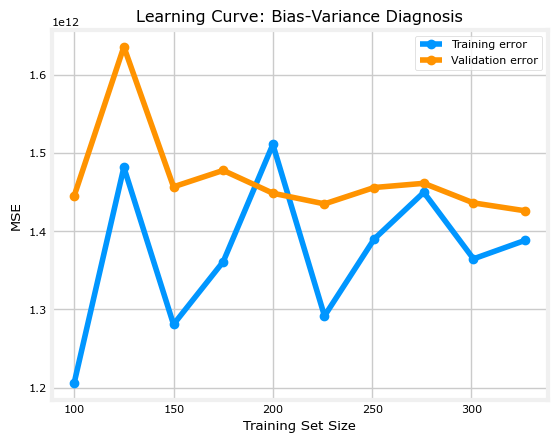

In [ ]:
plot_learning_curve(X_train, y_train, X_val, y_val) #train and validation curve [small dataset size, large difference]

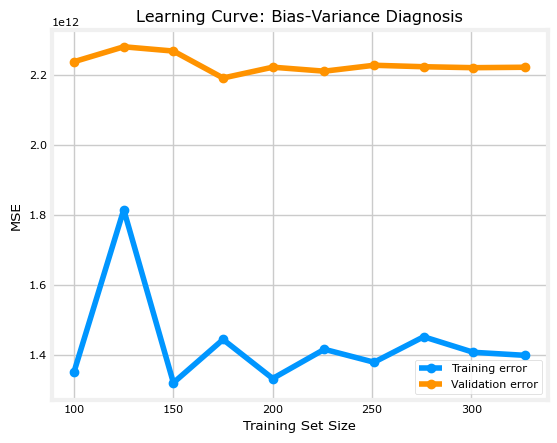

In [ ]:
plot_learning_curve(X_train, y_train, X_test, y_test) # overfitting [difference between train and test is large]